In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pygplates
import numpy as np
from Plate_Circuit_Segmenter_aux import calculate_rot_matrix_from_euler_pole, search_for_plateIDs, interpolate_rotation_files
import os
import cartopy.crs as ccrs
import vaes_func as vfunc
import cartopy.feature as cfeature


In [1]:
#Reads in the dataframes
total_circuit_rot_file = r"C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\Torsvik_Cocks_HybridRotationFile.rot"
col_names = ["plate_id", "age", "lat", "lon", "angle", "rel_plate"]
rot_data = np.loadtxt(r'C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\Torsvik_Cocks_HybridRotationFile.rot', comments='!')
df = pd.read_csv(r"C:\Users\Usuario\Documents\PMAGpythonRotation\results\results.csv")


NameError: name 'np' is not defined

In [3]:
#Assign PlateIDs to each datapoint
#Cell for using the plate shape-files to automatically assign each point in the dataset to a plate ID.

from attr import define

rotation_model = pygplates.RotationModel(r'C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\Torsvik_Cocks_HybridRotationFile.rot')
static_polygons_filename = r'C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\CEED6_LAND.gpml'
input_points_filename = df

def assign_plate_id(static_polygons_filename, rotation_model, lat, lon):
    
    # Create a point geometry
    point = pygplates.PointOnSphere(lat, lon)
    
    # Create a feature and assign the geometry
    point_feature = pygplates.Feature()
    point_feature.set_geometry(point)
    
    # Partition the feature
    partitioned_features = pygplates.partition_into_plates(
        static_polygons_filename,
        rotation_model,
        [point_feature]
    )
    
    # Extract assigned plate ID
    if partitioned_features:
        return partitioned_features[0].get_reconstruction_plate_id()
    else:
        return None

for index, row in df.iterrows():
    lat = row['slat']
    lon = row['slon']
    assigned_plate = assign_plate_id(static_polygons_filename, rotation_model, lat, lon)
    df.at[index, 'assigned_plate_id'] = assigned_plate
    print(f"Point at ({lat}, {lon}) is assigned to plate ID: {assigned_plate}")

Point at (55.5, -4.6) is assigned to plate ID: 303
Point at (50.6, -3.4) is assigned to plate ID: 0
Point at (57.5, -1.8) is assigned to plate ID: 303
Point at (56.2, -3.1) is assigned to plate ID: 303
Point at (54.8, -5.0) is assigned to plate ID: 303
Point at (51.2, -3.3) is assigned to plate ID: 0
Point at (51.1, -3.4) is assigned to plate ID: 315


In [4]:
#Calculating Total Reconstruction Poles for each datapoint within df

ref_plate = 0

df['EPs'] = None
ref_poles,EPs = [],[]
for i in range(len(df)):
    EP = vfunc.tr_pole_2(df['assigned_plate_id'][i],ref_plate,rot_data,df['age'][i],multi_t=False)
    #print(df['assigned_plate_id'][i],ref_plate,df['age'][i])
    plat_0, plon_0 = -90,0     # reference pole is south geographic pole
    rlon,rlat=vfunc.pt_rot([EP[0],EP[1],-1*EP[2]],[plat_0],[plon_0])   # rotate with total reconstruction pole (inverted angle -> to rotate pole to coordinate system of plate)
    ref_poles.append([rlon,rlat]) # store longitude and latitude of reference pole
    EPs.append(EP)
    df.loc[i, ['EP_lat', 'EP_lon', 'EP_angle']] = EP




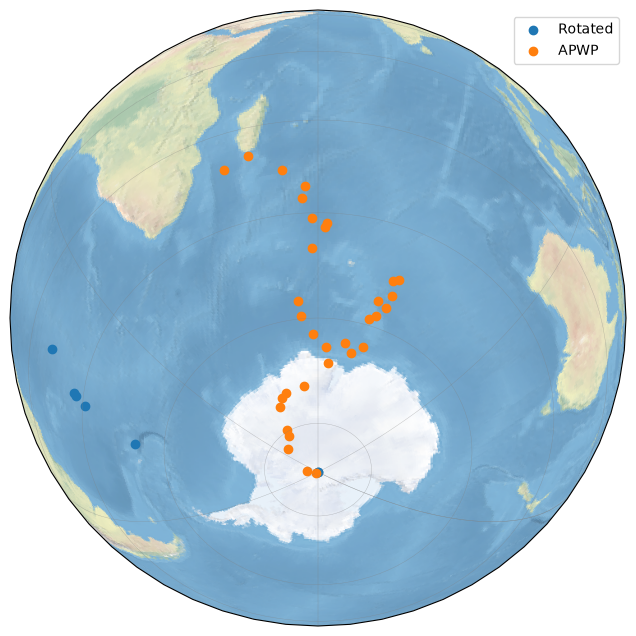

In [5]:
APWP = pd.read_excel(r"C:\Users\Usuario\Documents\PMAGpythonRotation\data\Global_APWP_Vaes_et_al_2023.xlsx", header=[0, 1])
APWP_lat = APWP['South Africa']['Latitude']
APWP_lon = APWP['South Africa']['Longitude']

ref_lons = [p[0] for p in ref_poles]
ref_lats = [p[1] for p in ref_poles]

fig = plt.figure(figsize=(8, 8))


ax = plt.axes(projection=ccrs.Orthographic(60,-60))
ax.set_global()
# ax = plt.axes(projection=ccrs.Mercator(central_longitude=100, max_latitude=0))

ax.scatter(ref_lons, ref_lats, transform=ccrs.Geodetic(), label="Rotated")

ax.stock_img()          # bundled raster image — no download

ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

#ax.scatter(calculated_lons, calculated_lats, transform=ccrs.Geodetic(), label="Calculated")
#ax.scatter(180-orig_lons, -orig_lats, transform=ccrs.Geodetic(), label="Original")
ax.scatter(APWP_lon, APWP_lat, transform=ccrs.Geodetic(), label="APWP")
ax.legend()

plt.show()

In [6]:

# Pre-create columns (avoids repeated .loc assignments in the loop)
df['EP_lat'] = None
df['EP_lon'] = None
df['EP_angle'] = None
df['ref_lat'] = None
df['ref_lon'] = None

ref_poles = []
EPs = []

plat_0, plon_0 = -90, 0  # reference pole is south geographic pole

for i in range(len(df)):
    EP = vfunc.tr_pole_2(
        df['assigned_plate_id'][i], ref_plate, rot_data,
        df['age'][i], multi_t=False
    )

    rlon, rlat = vfunc.pt_rot(
        [EP[0], EP[1], -1 * EP[2]],
        [plat_0], [plon_0]
    )

    # Build a dict carrying coordinates + metadata
    pole_record = {
        'ref_lon':  float(rlon),
        'ref_lat':  float(rlat),
        'EP_lon':   float(EP[0]),
        'EP_lat':   float(EP[1]),
        'EP_angle': float(EP[2]),
        'name':     df['name'][i]               if 'name' in df.columns else None,
        'age':      df['age'][i],
        'plate_id': df['assigned_plate_id'][i],
        'index':    i,
    }
    ref_poles.append(pole_record)
    EPs.append(EP)

    df.loc[i, ['EP_lat', 'EP_lon', 'EP_angle', 'ref_lat', 'ref_lon']] = \
        [EP[1], EP[0], EP[2], rlat, rlon]

In [7]:
ref_poles_df = pd.DataFrame(ref_poles)

# Convenient arrays for scatter
ref_lons = ref_poles_df['ref_lon'].tolist()
ref_lats = ref_poles_df['ref_lat'].tolist()

In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    ref_poles_df,
    lon='ref_lon', lat='ref_lat',
    hover_name='name',
    hover_data=['age', 'plate_id', 'EP_lon', 'EP_lat', 'EP_angle'],
    projection='orthographic',
)

ax.scatter(APWP_lon, APWP_lat, transform=ccrs.Geodetic(), label="APWP")

fig =px.scatter_geo(
    APWP,
    lon=APWP['South Africa']['Longitude'], lat=APWP['South Africa']['Latitude'],
    projection='orthographic'
)
fig.update_layout(geo=dict(showland=True, landcolor='lightgray',
                           showocean=True, oceancolor='lightblue'))
fig.show()

TypeError: scatter_geo() got an unexpected keyword argument 'colour'